In [2]:
import pandas as pd
import numpy as np
import itertools
from scipy.spatial.distance import pdist, squareform
from joblib import Parallel, delayed
import dask.dataframe as dd
import scanpy as sc
from scipy.sparse import csr_matrix, coo_matrix
from scipy.linalg import eigh
import torch
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'


## Simulate single cell perturbation data from a prior knowledge graph
## Implementation based on the simulation framework

In [3]:
# Step 1: Use scanpy's pre-computed neighbors (k=30, Jaccard metric)
# Note: scanpy already computed k=30 neighbors with Jaccard metric in Cell 5
prior_graph_ad = sc.read_h5ad("gograph_ad_largest.h5ad")
G = prior_graph_ad.X.shape[0]  # Number of genes
print(f"Number of genes: {G}")

# Use the neighbors graph already built by scanpy
# obsp['distances'] contains Jaccard distances (1 - similarity) for k=30 neighbors
# obsp['connectivities'] contains the connectivity matrix (UMAP-smoothed)
print("Using scanpy's pre-computed neighbors (k=30, Jaccard metric)...")

# Get the KNN connectivity mask (which edges are kept in k=30 graph)
knn_mask = prior_graph_ad.obsp['connectivities'] > 0  # Boolean mask for k=30 neighbors
print(f"KNN graph edges: {knn_mask.nnz // 2}")  # Divide by 2 for undirected

# Convert scanpy's distances to similarities: J_tilde = 1 - distance
# This gives us J_tilde for the k=30 neighbors only (sparse)
J_tilde_sparse = prior_graph_ad.obsp['distances'].copy()
J_tilde_sparse.data = 1.0 - J_tilde_sparse.data  # Convert distance to similarity
J_tilde_sparse.eliminate_zeros()

# Convert to dense matrix for element-wise operations with D
# We only need the k=30 neighbors, so this is much smaller than full matrix
J_tilde_knn = J_tilde_sparse.toarray()
# Ensure diagonal is 1 (gene similarity with itself)
np.fill_diagonal(J_tilde_knn, 1.0)

print(f"J_tilde (KNN) shape: {J_tilde_knn.shape}")
print(f"J_tilde (KNN) non-zero: {np.count_nonzero(J_tilde_knn)}")
print(f"J_tilde (KNN) range: [{J_tilde_knn[J_tilde_knn>0].min():.4f}, {J_tilde_knn.max():.4f}]")

Number of genes: 2985
Using scanpy's pre-computed neighbors (k=30, Jaccard metric)...
KNN graph edges: 71610
J_tilde (KNN) shape: (2985, 2985)
J_tilde (KNN) non-zero: 89240
J_tilde (KNN) range: [0.0062, 1.0000]


In [ ]:
# Step 2: Apply random direction matrix D to KNN similarity matrix
# J = KNN_{k=30}(J_tilde) * D, where D \in {-1,1}^{G x G} with all-one diagonal
# Note: KNN mask is already applied via scanpy's neighbors

print("Applying random direction matrix D...")

# Create random direction matrix D \in {-1,1}^{G x G} with all-one diagonal
np.random.seed(42)
# Create symmetric matrix with random signs
# For k=30 neighbors, we only need D for the edges that exist
D = squareform(np.random.choice([-1, 1], size=G * (G-1) // 2, p=[0.5, 0.5]))
np.fill_diagonal(D, 1)  # All-one diagonal

# Apply D to J_tilde_knn (element-wise multiplication)
# J = KNN(J_tilde) ⊙ D
J = J_tilde_knn * D

print(f"J shape: {J.shape}")
print(f"J non-zero elements: {np.count_nonzero(J)}")
print(f"J range: [{J.min():.4f}, {J.max():.4f}]")
print(f"J positive edges: {np.sum(J > 0)}")
print(f"J negative edges: {np.sum(J < 0)}")

Applying random direction matrix D...
J shape: (2985, 2985)
J non-zero elements: 89240
J range: [-1.0000, 1.0000]
J positive edges: 46015
J negative edges: 43225


In [ ]:
# Step 3: Estimate loading matrix L and noise variance sigma^2 from similarity matrix J
# According to the framework: J = LL^T + diag(sigma^2)
# Solution: Use top d eigenvectors and eigenvalues of J

def estimate_loadings_from_similarity(J, n_factors):
    """
    Estimate loading matrix L (Gxd) and noise variance sigma^2 (G,) from similarity matrix J.
    
    J = VΛV^T = sum lambda_g v_g v_g^T, where lambda_1 >= lambda_2 >= ... >= lambda_G
    L_hat = lambda_d lambda_d^(1/2), where V_d = [v_1, ..., v_d], lambda_d = diag(lambda_1, ..., lambda_d)
    sigma^2_g = sum_{j=d+1}^G lambda_j v_{g,j}^2, for g = 1, ..., G
    
    Parameters:
    -----------
    J : np.ndarray, shape (G, G)
        Similarity matrix
    n_factors : int
        Number of latent factors (d)
    
    Returns:
    --------
    L : np.ndarray, shape (G, d)
        Loading matrix
    sigma_sq : np.ndarray, shape (G,)
        Noise variance for each gene
    """
    G = J.shape[0]
    d = min(n_factors, G)
    
    print(f"Estimating loadings from similarity matrix (G={G}, d={d})...")
    
    # Eigendecomposition: J = VΛV^T
    eigvals, eigvecs = eigh(J)
    
    # Sort eigenvalues in descending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    eigval_rawsum = np.sum(np.abs(eigvals))
    
    # Ensure non-negative eigenvalues
    eigvals = np.maximum(eigvals, 0)
    eigval_truncsum = np.sum(np.abs(eigvals))
    
    # Extract top d eigenvalues and eigenvectors
    Lambda_d = np.diag(np.sqrt(eigvals[:d]))  # (d, d)
    V_d = eigvecs[:, :d]  # (G, d)
    eigval_usedsum = np.sum(np.abs(eigvals[:d]))
    
    # Estimate loading matrix: L = V_d lambda_d^(1/2)
    L = V_d @ Lambda_d  # (G, d)
    
    # Estimate noise variance: sigma_g^2 = sum_{j=d+1}^G lambda_j v_{g,j}^2
    if d < G:
        remaining_eigvals = eigvals[d:]
        remaining_eigvecs = eigvecs[:, d:]  # (G, G-d)
        sigma_sq = np.sum(remaining_eigvals[None, :] * (remaining_eigvecs ** 2), axis=1)
    else:
        sigma_sq = np.zeros(G)
    
    # Ensure positive variance
    sigma_sq = np.maximum(sigma_sq, 1e-6)
    
    # Verify reconstruction: J ≈ LL^T + diag(sigma^2)
    J_recon = L @ L.T + np.diag(sigma_sq)
    J_indep = np.eye(G)
    recon_error = np.linalg.norm(J - J_recon, 'fro')
    baseline_error = np.linalg.norm(J - J_indep, 'fro')
    print(f"Reconstruction error (Frobenius norm): {recon_error:.4f}")
    print(f"Baseline error (Frobenius norm): {baseline_error:.4f}")
    print(f"Reconstruction ratio: {(baseline_error - recon_error) / baseline_error:.4f}")
    print(f"Eigenvalue ratio:\n  truncated: {eigval_truncsum / eigval_rawsum:.4f}\n  used: {eigval_usedsum / eigval_rawsum:.4f}")
    
    return L, sigma_sq, (eigvals, eigvecs)



In [ ]:
# Simulation parameters
n_celltype = 2  # Number of cell types (including control c=0)
n_celleach = 100  # Number of cells per condition
n_perturb = 10  # Number of perturbation conditions
n_batch = 2  # Number of batches (including control b=0)
n_latent = 128  # Number of latent factors (d)
alpha = 0.2
beta = 0.01
perturbation_strength_mean = 5.0
perturbation_strength_std = 2.5

print(f"\nSimulation parameters:")
print(f"  Number of genes (G): {G}")
print(f"  Number of cell types (C): {n_celltype}")
print(f"  Cells per condition: {n_celleach}")
print(f"  Number of perturbations: {n_perturb}")
print(f"  Number of batches (B): {n_batch}")
print(f"  Latent dimension (d): {n_latent}")
print(f"  Cell type heterogeneity (alpha): {alpha}")
print(f"  Batch heterogeneity (β): {beta}")
print(f"  Perturbation strength mean: {perturbation_strength_mean}")
print(f"  Perturbation strength std: {perturbation_strength_std}")



Simulation parameters:
  Number of genes (G): 2985
  Number of cell types (C): 2
  Cells per condition: 100
  Number of perturbations: 10
  Number of batches (B): 2
  Latent dimension (d): 128
  Cell type heterogeneity (α): 0.2
  Batch heterogeneity (β): 0.01
  Perturbation strength mean: 5.0
  Perturbation strength std: 2.5


In [ ]:
# Step 4: Estimate loading matrix L and noise variance sigma^2
np.random.seed(42)
L_hat, sigma_sq_hat, (eigvals, eigvecs) = estimate_loadings_from_similarity(J, n_factors=n_latent)
sigma_hat = np.sqrt(sigma_sq_hat)  # Standard deviation

print(f"\nEstimated parameters:")
print(f"  Loading matrix L shape: {L_hat.shape}")
print(f"  Noise std sigma^2 range: [{sigma_hat.min():.4f}, {sigma_hat.max():.4f}]")

Estimating loadings from similarity matrix (G=2985, d=128)...


Reconstruction error (Frobenius norm): 87.0724
Baseline error (Frobenius norm): 93.1964
Reconstruction ratio: 0.0657
Eigenvalue ratio:
  truncated: 0.8259
  used: 0.1480

Estimated parameters:
  Loading matrix L shape: (2985, 128)
  Noise std σ range: [0.2502, 1.2736]


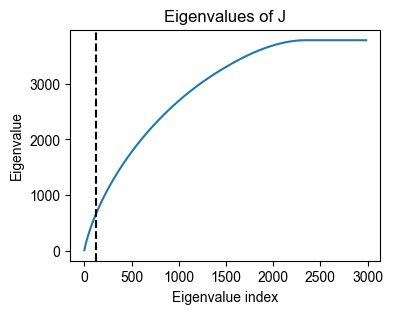

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(np.cumsum(eigvals))
ax.axvline(n_latent, color='k', linestyle='--')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalues of J')
plt.show()

In [ ]:
# Step 5: Generate expression profiles for multiple cell types and batches
# According to the framework:
# mu_c ~ N(0, alpha I) for c = 0, ..., C-1 (cell type mean vectors)
# sigma_b = max(0, sigma_hat + Delta sigma_b), where Delta sigma_b ~ N(0, beta I) for b = 0, ..., B-1 (batch noise levels)
# Control cells: x_i^{b,c,ctrl} = L_hat * z_i^{c,ctrl} + epsilon_i^b
#   where z_i^{c,ctrl} ~ N(mu_c, I), epsilon_i^b ~ N(0, diag(sigma_b^2))

def generate_celltype_batch_parameters(n_celltype, n_batch, n_latent, G, 
                                       alpha=1.0, beta=0.1):
    """
    Generate cell type mean vectors μ_c and batch noise levels sigma_b.
    
    Parameters:
    -----------
    n_celltype : int
        Number of cell types (C)
    n_batch : int
        Number of batches (B)
    n_latent : int
        Latent dimension (d)
    G : int
        Number of genes
    alpha : float
        Hyperparameter controlling cell type heterogeneity
    beta : float
        Hyperparameter controlling batch heterogeneity
    sigma_hat : np.ndarray, shape (G,)
        Baseline noise level (typical batch b=0)
    
    Returns:
    --------
    mu_c : np.ndarray, shape (C, d)
        Cell type mean vectors
    sigma_b : np.ndarray, shape (B, G)
        Batch noise levels
    """
    np.random.seed(42)
    
    # Generate cell type mean vectors: mu_c ~ N(0, alpha I)
    mu = np.random.randn(n_celltype, n_latent) * np.sqrt(alpha)
    # Typical cell type (c=0) has mu_0 = 0
    mu[0] = 0.0
    
    # Generate systematic batch noise levels: nu_b ~ N(0, beta I)
    nu = np.random.randn(n_batch, G) * np.sqrt(beta)
    # Typical batch (b=0) has nu_0 = 0
    nu[0] = 0.0   
    return mu, nu

def generate_perturbation_indices(G: int, size_perturb: int | tuple[int, int], add_control: bool = True, weights: list[float] = None):
    """
    Generate perturbation indices for each perturbation condition.
    
    Parameters:
    -----------
    G : int
        Number of genes
    size_perturb : int | tuple[int, int]
        Number of perturbations or (number of perturbations, number of genes per perturbation)
    
    Returns:
    --------
    perturbation_indices : np.ndarray, shape size_perturb
        Perturbation indices
    """
    if isinstance(size_perturb, int):
        size_perturb = (size_perturb, 1)
        
    possible_psi = list(itertools.combinations(range(G), size_perturb[1]))
    possible_weights = []
    if weights is None:
        possible_weights = [1] * len(possible_psi)
    else:
        assert len(weights) == G, "weights must be a list of length G"
        possible_weights = [np.sum(weights[pi] for pi in psi) for psi in possible_psi]
    possible_weights = np.array(possible_weights) / np.sum(possible_weights)
    psidx_list = np.random.choice(len(possible_psi), size=size_perturb[0], replace=False, p=possible_weights)
    if add_control:
        psidx_list = np.concatenate([psidx_list, [-1]])
    return [possible_psi[i] if i != -1 else None for i in psidx_list]


mu, nu = generate_celltype_batch_parameters(
    n_celltype=n_celltype, n_batch=n_batch, n_latent=n_latent, G=G, alpha=alpha, beta=beta
)
psi_list = generate_perturbation_indices(
    G=G, 
    size_perturb=n_perturb,
    add_control=True,
    weights=np.linalg.norm(L_hat, axis=1)**2
)

print(f"\nGenerated cell type and batch parameters:")
print(f"  Cell type means mu_c shape: {mu.shape}")
print(f"  Batch noise levels nu_b shape: {nu.shape}")
print(f"  mu_c[0] (control): {mu[0][:5]}... (should be all zeros)")
print(f"  nu_b[0] range: [{nu[0][:5]}... (should be all zeros)")

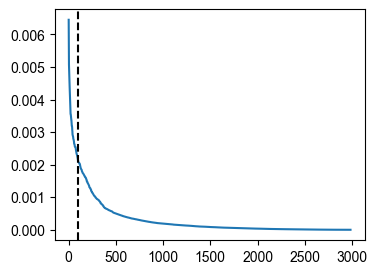

In [10]:
w = np.linalg.norm(L_hat, axis=1) ** 2
w = sorted(w / w.sum())[::-1]
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(w)
ax.axvline(100, color='k', linestyle='--')
plt.show()


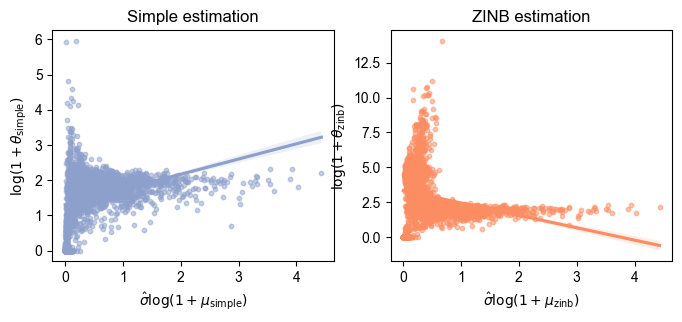

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
sns.regplot(
    x=sigma_hat * np.log1p(prior_graph_ad.obs['average_counts.simple']), 
    y=np.log1p(prior_graph_ad.obs['dispersions.simple']), 
    order=1, 
    ax=ax[0],
    scatter_kws={'alpha': 0.5, 's': 10},
    color=sns.color_palette('Set2')[2]
)
ax[0].set_xlabel(r'$\hat{\sigma} \log (1+\mu_\text{simple})$')
ax[0].set_ylabel(r'$\log (1+\theta_\text{simple})$')
ax[0].set_title('Simple estimation')
sns.regplot(
    x=sigma_hat * np.log1p(prior_graph_ad.obs['average_counts.zinb']), 
    y=np.log1p(prior_graph_ad.obs['dispersions.zinb']),
    order=1, 
    ax=ax[1],
    scatter_kws={'alpha': 0.5, 's': 10},
    color=sns.color_palette('Set2')[1]
)
ax[1].set_title('ZINB estimation')
ax[1].set_xlabel(r'$\hat{\sigma} \log (1+\mu_\text{zinb})$')
ax[1].set_ylabel(r'$\log (1+\theta_\text{zinb})$')
plt.savefig('figs/sigmamu_vs_dispersion.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Step 7: Generate perturbed cell expression profiles
# According to the framework:
# x_i^{b,c,psi} = L_hat * z_i^{c,psi} + epsilon_i^b
# where z_i^{c,psi} ~ N(μ_c + s_i^psi, I), s_i^psi = gamma_i * L_hat^T * delta_psi
# This is equivalent to: x_i^{b,c,psi} ≈ x_i^{b,c,ctrl} + gamma_i * J_hat * delta_psi

def gaussian_distribution(mean: float, std: float, n: int):
    return np.random.randn(n) * std + mean

def generate_perturbed_cells(L_hat: np.ndarray, sigma_hat: np.ndarray,
                             mu: np.ndarray, nu: np.ndarray, 
                             psi_list: list[list[int]],
                             n_celleach: int,
                             gamma_mean: float, 
                             gamma_std: float,
                             zinb_sampling: bool = False,
                             mean_log1p_smp: float = None,
                             var_log1p_smp: float = None
                             ):
    """
    Generate perturbed cell expression profiles.
    
    Parameters:
    -----------
    L_hat : np.ndarray, shape (G, d)
        Loading matrix
    sigma_hat : np.ndarray, shape (G,)
        noise level
    mu : np.ndarray, shape (C, d)
        Cell type mean vectors
    nu : np.ndarray, shape (B, G)
        Batch noise shifts
    psi_list : list[list[int]]
        Perturbation indices
    n_celleach : int
        Number of cells per condition
    gamma_mean : float
        Mean perturbation strength (gamma)
    gamma_std : float
        Std of perturbation strength
    
    Returns:
    --------
    X_pert : np.ndarray, shape (N_pert, G)
        Perturbed cell expression profiles
    Z_pert : np.ndarray, shape (N_pert, d)
        Latent variables
    metadata : pd.DataFrame
        Metadata (cell_type, batch, condition, perturbed_gene)
    """
        
    G, d = L_hat.shape    
    X_pert = []
    Z_pert = []
    metadata_rows = []
    
    for psi in psi_list:
        delta_psi = np.zeros(G)
        if psi is None:
            n_scale = 5
        else:
            n_scale = 1
            for pi in psi:
                delta_psi[pi] = 1.0
        for c, mu_c in enumerate(mu):
            for b, nu_b in enumerate(nu):
                # Generate perturbation strengths: gamma_i ~ N(gamma_mean, gamma_std²)
                gamma = np.random.normal(
                    gamma_mean, 
                    gamma_std, 
                    n_celleach * n_scale
                )
                
                # Generate latent variables with perturbation: z_i^{c,psi} ~ N(mu_c + s_i^psi, I)
                # where s_i^psi = gamma_i * L_hat^T * sigma_psi
                s_psi = gamma[:, None] * (L_hat.T @ delta_psi)  # (n_celleach, d)
                Z_batch = np.random.randn(n_celleach * n_scale, d) + mu_c + s_psi
                
                # Generate noise: epsilon_i^b ~ N(0, diag(sigma_b^2))
                E_batch = np.random.randn(n_celleach * n_scale, G) * sigma_hat + nu_b
                
                # Generate expression: x_i^{b,c,psi} = L_hat * z_i^{c,psi} + epsilon_i^b
                X_batch = Z_batch @ L_hat.T + E_batch
                
                X_pert.append(X_batch)
                Z_pert.append(Z_batch)
                
                # Metadata
                for i in range(n_celleach * n_scale):
                    metadata_rows.append({
                        'cell_type': f'c{c}',
                        'batch': f'b{b}',
                        'condition': f'psi{psi}',
                        'perturbation_strength': gamma[i],
                        'cell_id': f'perturb_{psi}_c{c}_b{b}_i{i}'
                    })
    
    X_pert = np.vstack(X_pert)  # (N_pert, G)
    Z_pert = np.vstack(Z_pert)  # (N_pert, d)
    metadata_pert = pd.DataFrame(metadata_rows)
    
    if zinb_sampling:
        assert mean_log1p_smp is not None and var_log1p_smp is not None
        a = mean_log1p_smp
        b = np.sqrt(var_log1p_smp / (np.diag(L_hat @ L_hat.T + (sigma_hat ** 2)) + 1e-8))
        Y_pert = np.ceil(np.exp(a + b * X_pert) - 1).astype(int)
        return X_pert, Y_pert, Z_pert, metadata_pert
    return X_pert, Z_pert, metadata_pert

# Generate perturbed cells
X_pert, Y_pert, Z_pert, metadata_pert = generate_perturbed_cells(
    L_hat=L_hat, sigma_hat=sigma_hat, 
    mu=mu, nu=nu, psi_list=psi_list,
    n_celleach=n_celleach,
    gamma_mean=perturbation_strength_mean,
    gamma_std=perturbation_strength_std,
    zinb_sampling=True,
    mean_log1p_smp=prior_graph_ad.obs['mean_log1p_smp'].values,
    var_log1p_smp=prior_graph_ad.obs['var_log1p_smp'].values
)

print(f"\nGenerated perturbed cells:")
print(f"  Expression matrix shape: {X_pert.shape}")
print(f"  Expression matrix shape: {Y_pert.shape}")
print(f"  Latent variables shape: {Z_pert.shape}")
print(f"  Metadata shape: {metadata_pert.shape}")


Generated perturbed cells:
  Expression matrix shape: (6000, 2985)
  Expression matrix shape: (6000, 2985)
  Latent variables shape: (6000, 128)
  Metadata shape: (6000, 5)


In [ ]:
# Step 8: Create AnnData object
sim_ad = sc.AnnData(
    X=Y_pert.copy(),
    obs=metadata_pert.set_index('cell_id'),
    var=prior_graph_ad.obs.copy(),
    varp=prior_graph_ad.obsp.copy(),
    varm={'L_hat': L_hat, 'sigma_hat': sigma_hat, },
    obsm={'Z_pert': Z_pert},
    layers={'counts': Y_pert.copy(), 'expression': X_pert.copy()}
)

# convert perturbed gene idx to gene name
sim_ad.obs['perturbation'] = sim_ad.obs['condition'].apply(
    lambda psi: 'control' 
    if psi == 'psiNone' 
    else '_'.join([prior_graph_ad.obs_names[i] for i in eval(psi.replace('psi', ''))])
)

# Store additional information
sim_ad.uns['simulation_params'] = {
    'n_celltype': n_celltype,
    'n_celleach': n_celleach,
    'n_perturb': n_perturb,
    'n_batch': n_batch,
    'n_latent': n_latent,
    'G': G,
    'alpha': alpha,
    'beta': beta,
    'mu': mu,
    'nu': nu,
    'perturbation_strength_mean': perturbation_strength_mean,
    'perturbation_strength_std': perturbation_strength_std
}

print(f"\nFinal simulation data:")
print(f"  Total cells: {sim_ad.n_obs}")
print(f"  Total genes: {sim_ad.n_vars}")
print(f"  Perturbed cells: {len(metadata_pert)}")
print(f"\nCondition distribution:")
print(sim_ad.obs['perturbation'].value_counts())


Final simulation data:
  Total cells: 6000
  Total genes: 2985
  Perturbed cells: 6000

Condition distribution:
perturbation
control      2000
DDX50         400
NIP7          400
EXOSC7        400
SP110         400
ZNF800        400
BIVM          400
CCNG2         400
SNRNP48       400
HIST1H2BL     400
LENG8         400
Name: count, dtype: int64


In [14]:
sim_ad.obs

,cell_type,batch,condition,perturbation_strength,perturbation
cell_id,,,,,
"perturb_(1552,)_c0_b0_i0",c0,b0,"psi(1552,)",4.445546,NIP7
"perturb_(1552,)_c0_b0_i1",c0,b0,"psi(1552,)",7.423423,NIP7
"perturb_(1552,)_c0_b0_i2",c0,b0,"psi(1552,)",3.421494,NIP7
"perturb_(1552,)_c0_b0_i3",c0,b0,"psi(1552,)",5.131316,NIP7
"perturb_(1552,)_c0_b0_i4",c0,b0,"psi(1552,)",3.110123,NIP7
...,...,...,...,...,...
perturb_None_c1_b1_i495,c1,b1,psiNone,9.629379,control
perturb_None_c1_b1_i496,c1,b1,psiNone,7.661936,control
perturb_None_c1_b1_i497,c1,b1,psiNone,7.033621,control


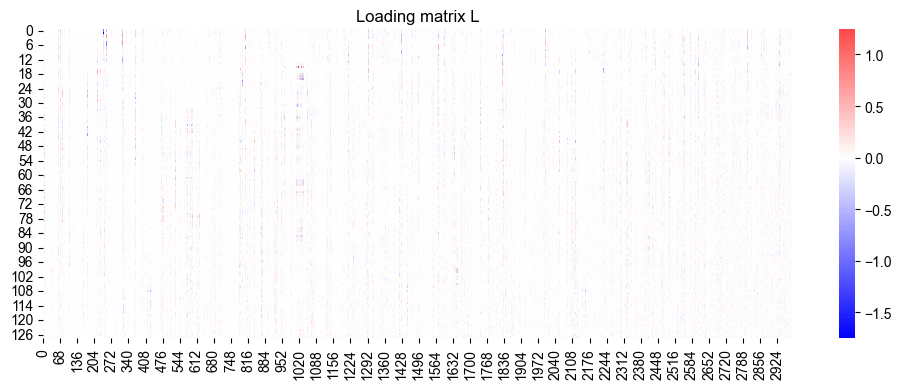

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(L_hat.T, cmap='bwr', center=0, ax=ax)
plt.title('Loading matrix L')
plt.tight_layout()
# plt.savefig('figs/L_hat.png', dpi=300)
plt.show()

In [16]:
sc.pp.filter_cells(sim_ad, min_genes=10)
sc.pp.filter_genes(sim_ad, min_cells=3)
sc.pp.normalize_total(sim_ad, target_sum=1e4)
sc.pp.log1p(sim_ad)
sc.pp.pca(sim_ad, n_comps=50)
sc.pp.neighbors(sim_ad)
sc.tl.umap(sim_ad)
sc.tl.leiden(sim_ad, flavor='igraph', n_iterations=2)

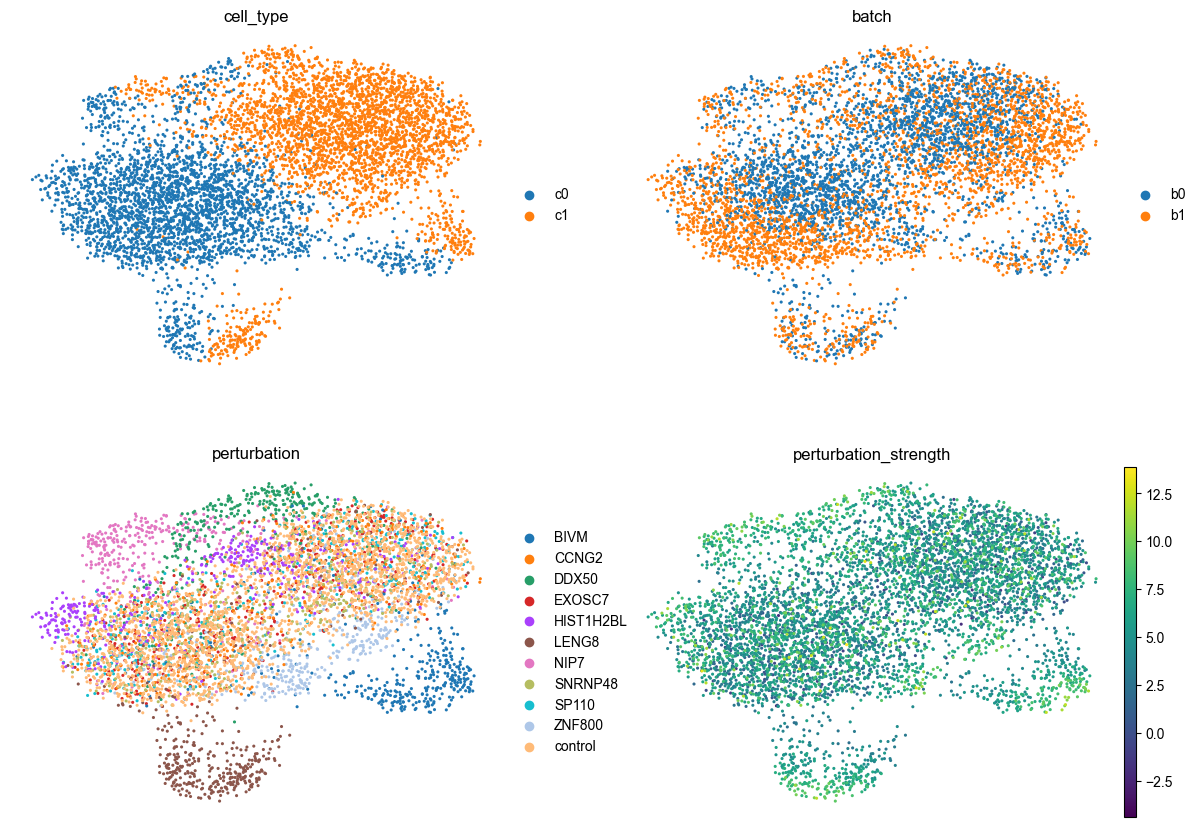

In [ ]:
sc.pl.umap(sim_ad, color=['cell_type', 'batch', 'perturbation', 'perturbation_strength'], ncols=2, frameon=False, show=False)
if n_perturb <= 12:
    plt.savefig('figs/umap_zinb_distribution.pdf', bbox_inches='tight')
plt.show()

In [18]:
sim_ad_gaussian = sim_ad.copy()
sim_ad_gaussian.X = sim_ad.layers['expression'].copy()
sc.pp.pca(sim_ad_gaussian, n_comps=50)
sc.pp.neighbors(sim_ad_gaussian)
sc.tl.umap(sim_ad_gaussian)

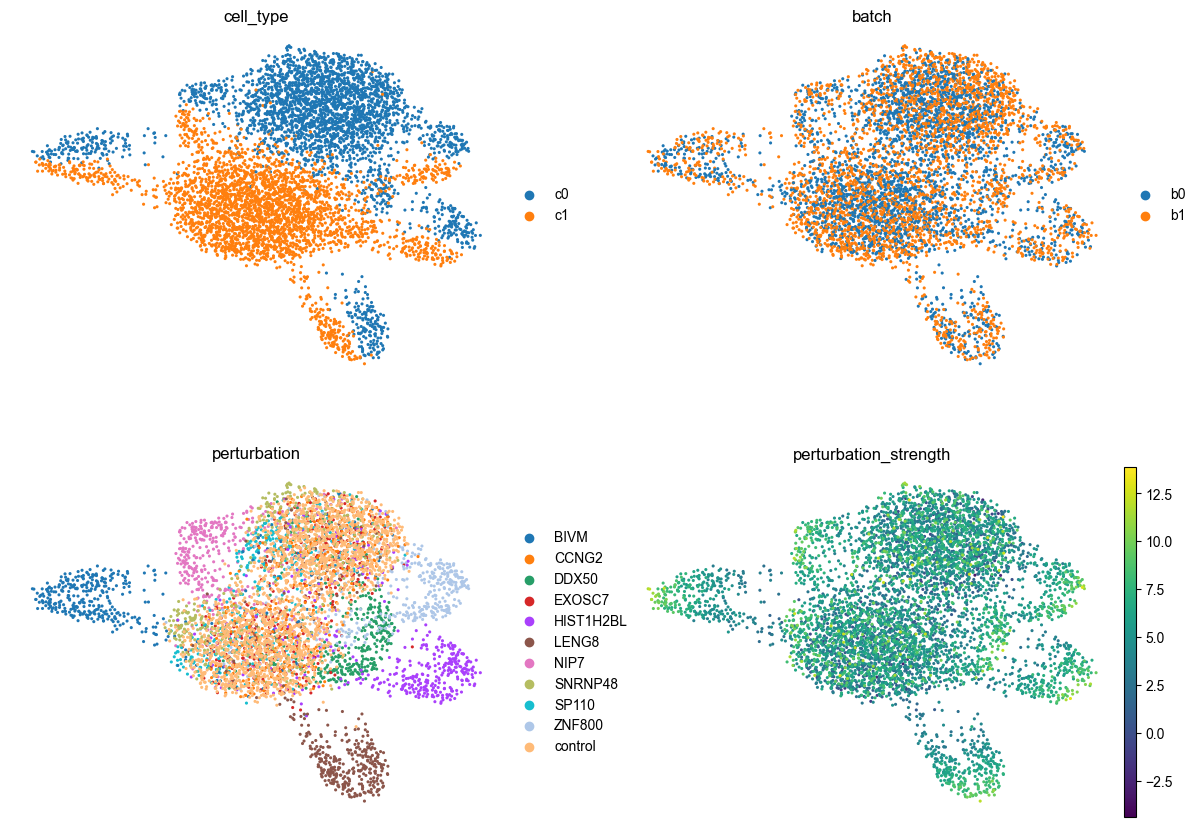

In [19]:
sc.pl.umap(sim_ad_gaussian, color=['cell_type', 'batch', 'perturbation', 'perturbation_strength'], ncols=2, frameon=False, show=False)
if n_perturb <= 12:
    plt.savefig('figs/umap_gaussian_distribution.pdf', bbox_inches='tight')
plt.show()

In [20]:
sim_ad_z = sim_ad.copy()
sim_ad_z.obsm['X_pca'] = sc.pp.pca(sim_ad_z.obsm['Z_pert'], n_comps=50, copy=True)
sc.pp.neighbors(sim_ad_z, use_rep='X_pca')
sc.tl.umap(sim_ad_z)


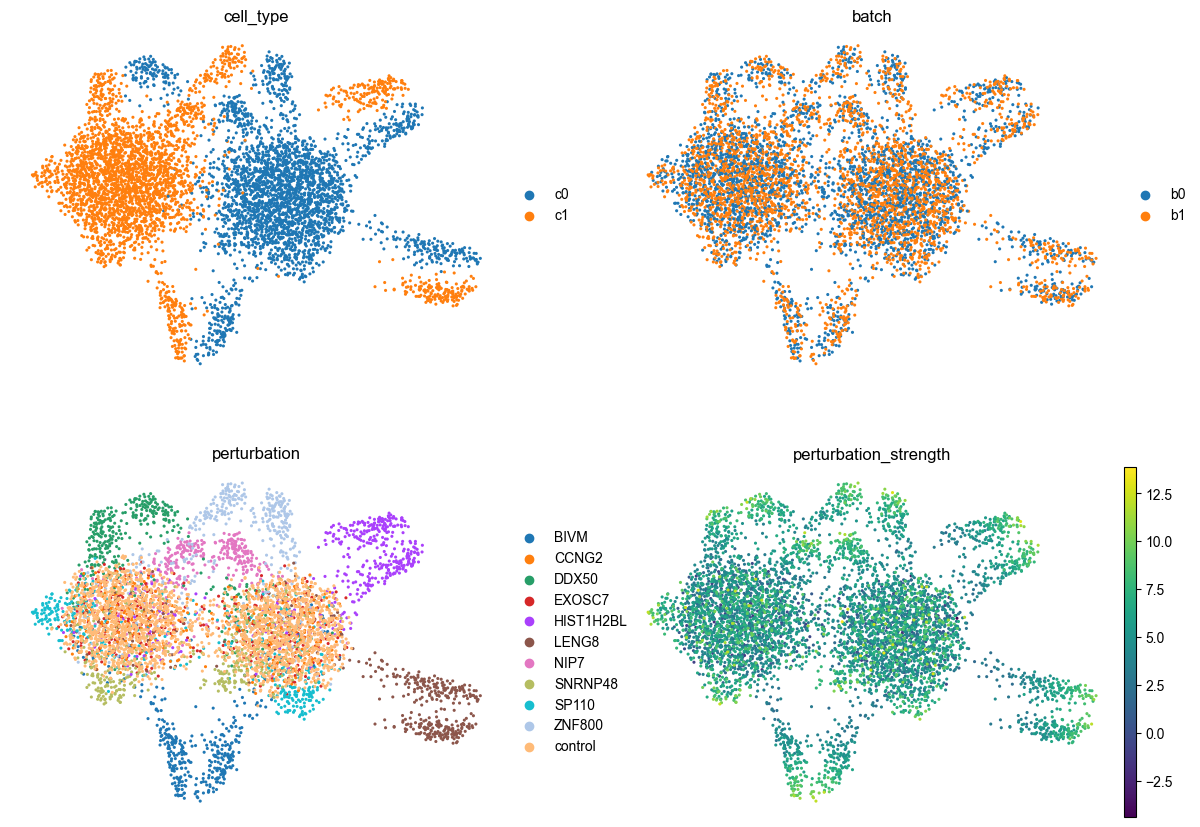

In [21]:
sc.pl.umap(sim_ad_z, color=['cell_type', 'batch', 'perturbation', 'perturbation_strength'], ncols=2, frameon=False, show=False)
if n_perturb <= 12:
    plt.savefig('figs/umap_latent_distribution.pdf', bbox_inches='tight')
plt.show()


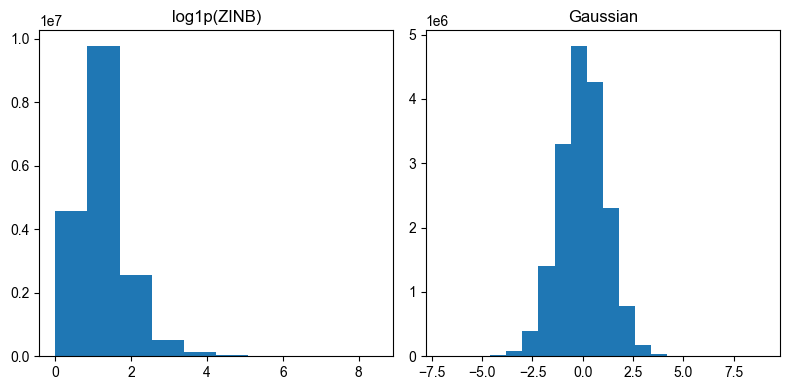

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(sim_ad.X.flatten(), bins=10)
axes[0].set_title('log1p(ZINB)')
mask = (-7 < sim_ad.layers['expression'].flatten()) & (sim_ad.layers['expression'].flatten() < 9)
axes[1].hist(sim_ad.layers['expression'].flatten()[mask], bins=20)
axes[1].set_title('Gaussian')
plt.tight_layout()
if n_perturb <= 12:
    plt.savefig('figs/expression_distribution.pdf', bbox_inches='tight')
plt.show()


In [23]:
sim_ad

AnnData object with n_obs × n_vars = 6000 × 2932
    obs: 'cell_type', 'batch', 'condition', 'perturbation_strength', 'perturbation', 'n_genes', 'leiden'
    var: 'average_counts.simple', 'dispersions.simple', 'dropout_rates.simple', 'average_counts.zinb', 'dispersions.zinb', 'dropout_rates.zinb', 'leiden', 'leiden.filtered', 'mean_log1p_smp', 'var_log1p_smp', 'n_cells'
    uns: 'simulation_params', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'cell_type_colors', 'batch_colors', 'perturbation_colors'
    obsm: 'Z_pert', 'X_pca', 'X_umap'
    varm: 'L_hat', 'sigma_hat', 'PCs'
    layers: 'counts', 'expression'
    obsp: 'distances', 'connectivities'
    varp: 'connectivities', 'connectivities.original', 'distances', 'distances.original'

In [24]:
sim_ad_csr = sim_ad.copy()
sim_ad_csr.X = csr_matrix(sim_ad.X)
sim_ad_csr.layers['counts'] = csr_matrix(sim_ad.layers['counts'])

In [ ]:
print(f"\nSimulation parameters:")
print(f"  Number of genes (G): {G}")
print(f"  Number of cell types (C): {n_celltype}")
print(f"  Number of perturbation conditions (P): {n_perturb}")
print(f"  Cells per condition: {n_celleach}")
print(f"  Number of batches (B): {n_batch}")
print(f"  Latent dimension (d): {n_latent}")
print(f"  Cell type heterogeneity (alpha): {alpha}")
print(f"  Batch heterogeneity (beta): {beta}")
print(f"  Perturbation strength mean: {perturbation_strength_mean}")
print(f"  Perturbation strength std: {perturbation_strength_std}")


Simulation parameters:
  Number of genes (G): 2985
  Number of cell types (C): 2
  Number of perturbation conditions (P): 10
  Cells per condition: 100
  Number of batches (B): 2
  Latent dimension (d): 128
  Cell type heterogeneity (α): 0.2
  Batch heterogeneity (β): 0.01
  Perturbation strength mean: 5.0
  Perturbation strength std: 2.5


In [26]:
suffix = f"b{n_batch}_c{n_celltype}_p{n_perturb}_d{n_latent}_re{perturbation_strength_mean}_rv{perturbation_strength_std}"

In [27]:
# sim_ad_csr.write_h5ad(f"sim_ad_b{n_batch}_c{n_celltype}_p{n_perturb}_d{n_latent}_re{perturbation_strength_mean}_rv{perturbation_strength_std}.h5ad")

In [28]:
del sim_ad_csr.uns['log1p']
del sim_ad_csr.uns['pca']

In [29]:
sim_ad_csr.write_h5ad(f"sim_ad_{suffix}_safe.h5ad", compression='gzip')

In [30]:
split_df = sim_ad_csr.obs[['cell_type']].rename(columns={'cell_type': 'subsplit'})
split_df

,subsplit
cell_id,
"perturb_(1552,)_c0_b0_i0",c0
"perturb_(1552,)_c0_b0_i1",c0
"perturb_(1552,)_c0_b0_i2",c0
"perturb_(1552,)_c0_b0_i3",c0
"perturb_(1552,)_c0_b0_i4",c0
...,...
perturb_None_c1_b1_i495,c1
perturb_None_c1_b1_i496,c1
perturb_None_c1_b1_i497,c1


In [31]:
np.random.seed(42)
split_df['split'] = np.random.choice(['train', 'val', 'test'], size=len(split_df), p=[0.7, 0.1, 0.2], replace=True)
split_df['split'] = split_df[['split', 'subsplit']].apply(lambda x: x['split'] if x['subsplit'] == 'c0' else 'test', axis=1)
split_df[['split', 'subsplit']].value_counts()

split  subsplit
test   c1          3000
train  c0          2118
test   c0           601
val    c0           281
Name: count, dtype: int64

In [32]:
split_df.to_parquet(f'split_df_{suffix}.parquet')